In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

t_span = (0, 50)

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 0,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': [0.05],
    't_eval_train': None, 'dt_train': 0.01, 't_span_train': (0, 25),
    'train_interpolation_dt': None,
    'threshold': [0.01, 0.05, 0.1], 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config, use_ESINDy=False, use_ridge=True)

rows are noise_level. there are 1 rows.
columns are threshold. there are 3 columns.
step 1 of 1


100%|██████████| 3/3 [00:01<00:00,  2.06it/s]


rows are noise_level. there are 1 rows.
columns are threshold. there are 3 columns.


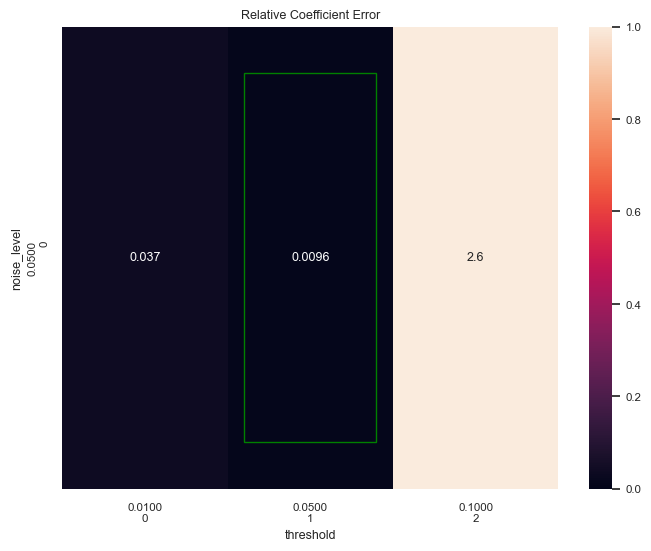

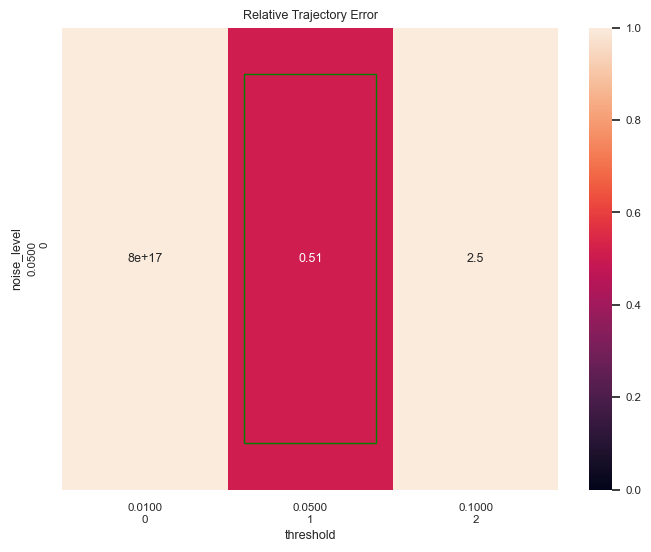

In [3]:
plot_heatmaps(experiment_config, results)

x0' = + 2.88348 1 + -0.64793 x1 + -0.17883 x0 x1 
x1' = + -0.10715 x1 


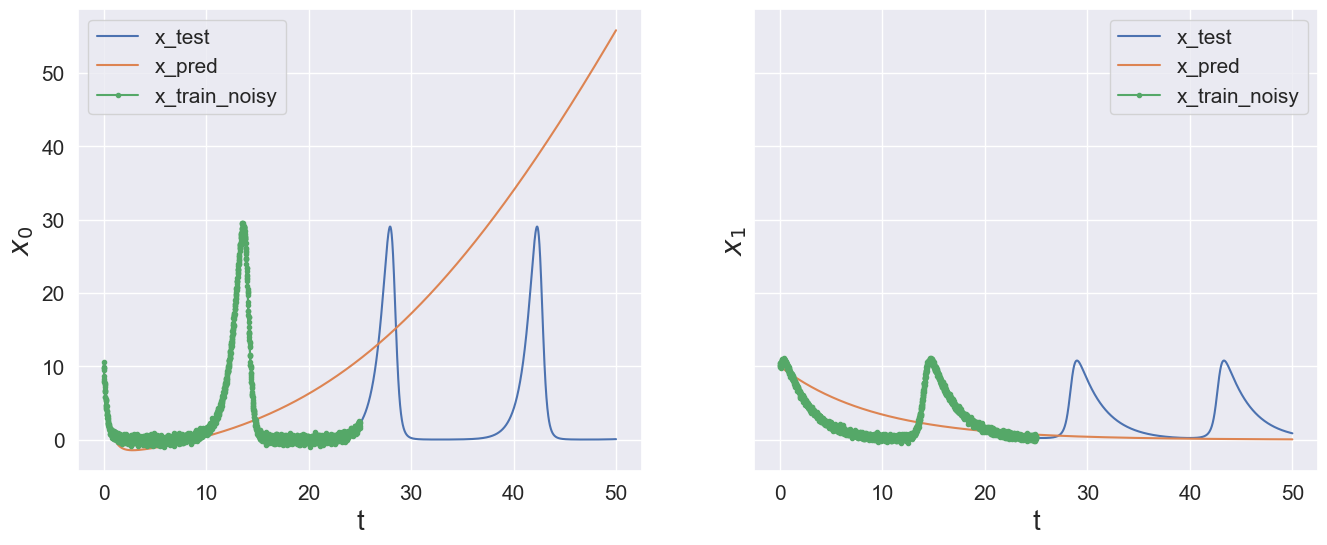

In [10]:
SMALL_SIZE = 15
MEDIUM_SIZE = 20

# plt.rcdefaults()
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize

display_single_result(experiment_config, results, 2, 0, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])

In [5]:
results2 = run_experiment(experiment_config, use_ESINDy=True, use_ridge=True)

rows are noise_level. there are 1 rows.
columns are threshold. there are 3 columns.
step 1 of 1


100%|██████████| 3/3 [00:05<00:00,  1.94s/it]


rows are noise_level. there are 1 rows.
columns are threshold. there are 3 columns.


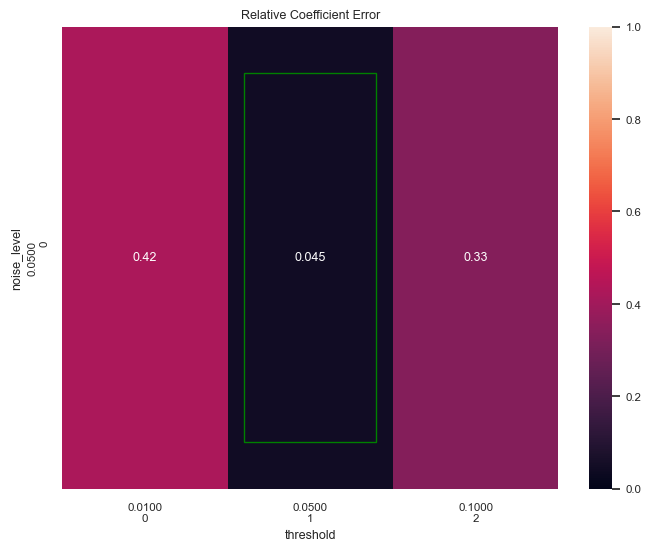

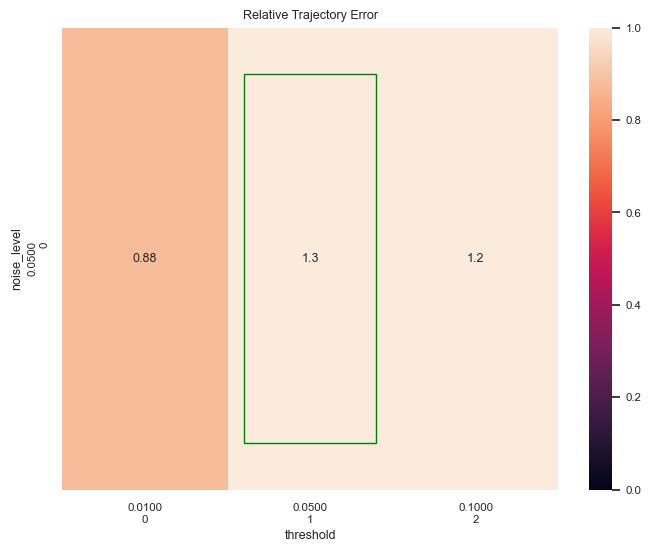

In [6]:
plot_heatmaps(experiment_config, results2)

x0' = + 1.07994 x0 + -0.39931 x0 x1 
x1' = + -0.34964 x1 + 0.08743 x0 x1 


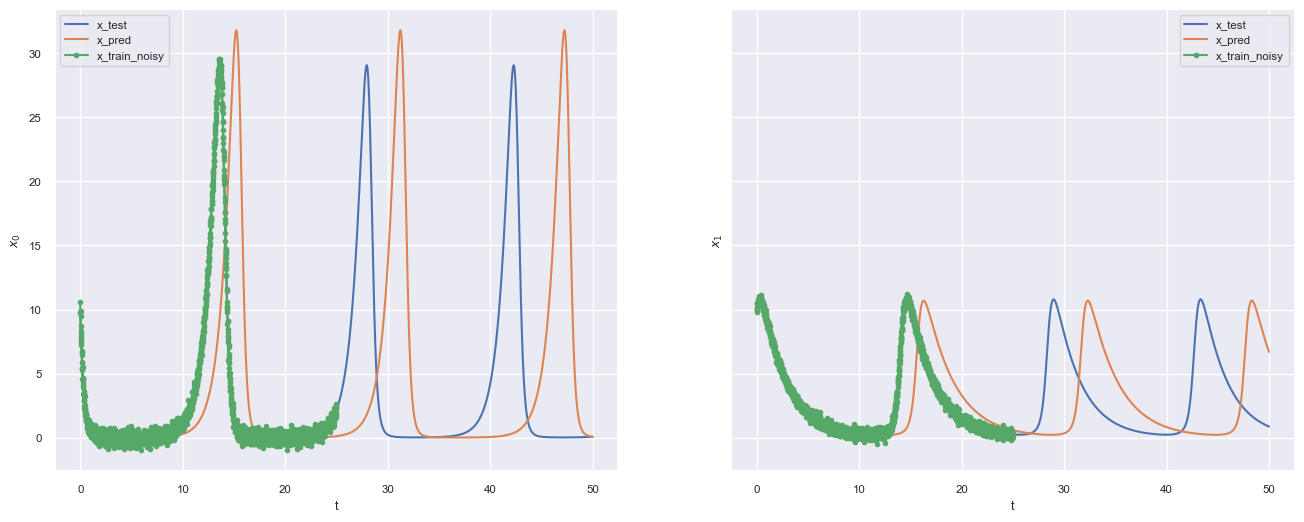

In [7]:
display_single_result(experiment_config, results2, 1, 0, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])

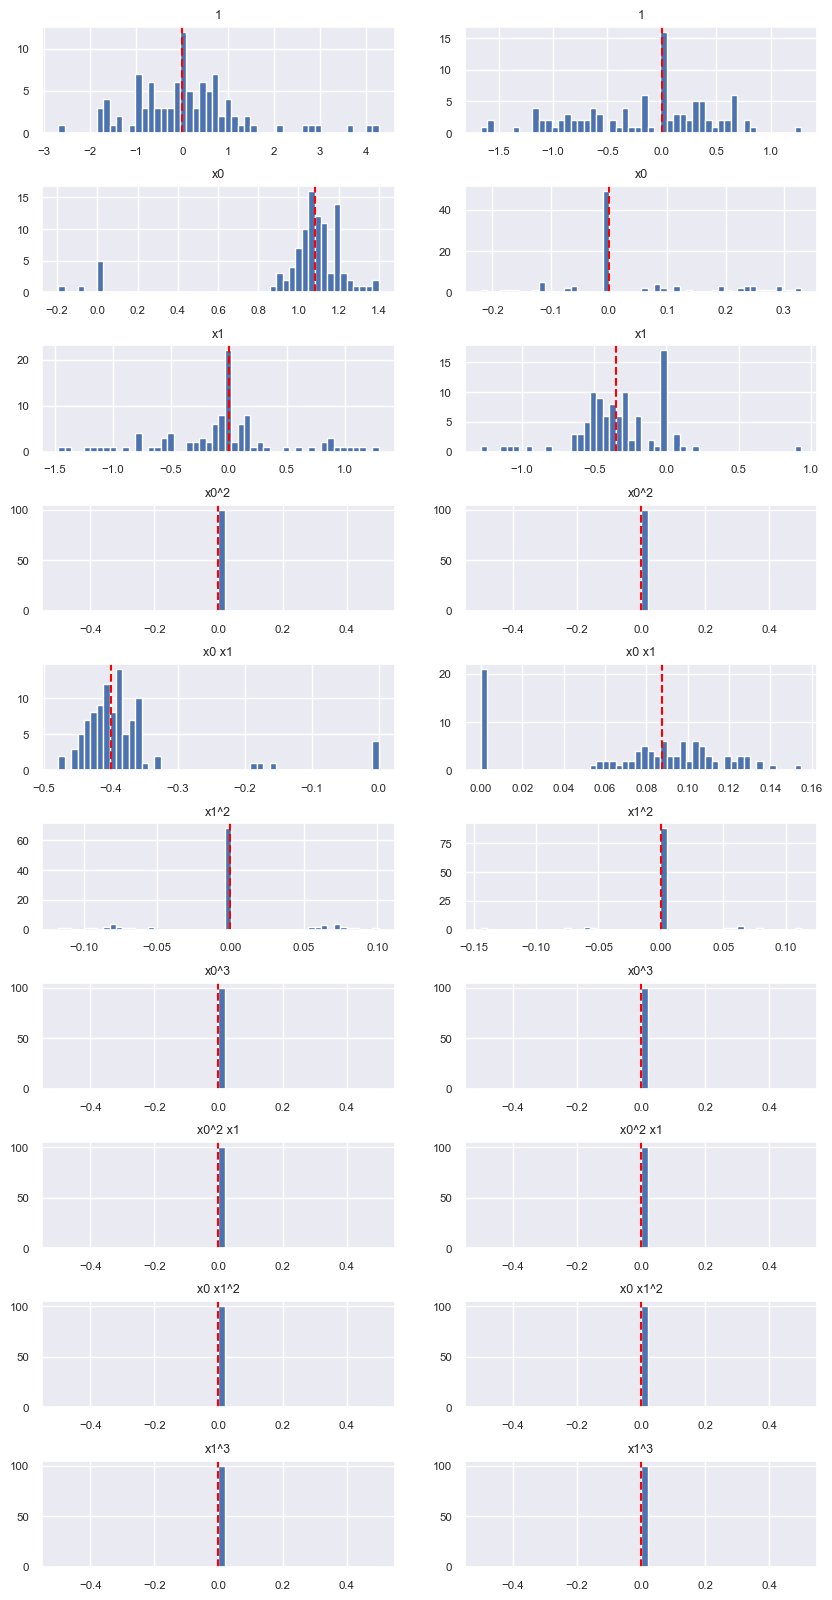

In [8]:
col = 1
model = results2[0][col]['model']

base_model = SINDyModel(2, 0.05)


n_shown_terms = 10

fig, axs = plt.subplots(n_shown_terms, 2, figsize=(10, 2*n_shown_terms))
for i in range(n_shown_terms):
    axs[i, 0].hist(model.Xis[:, i, 0], bins=50)
    axs[i, 0].axvline(np.median(model.Xis[:, i, 0]), color='red', linestyle='dashed')
    axs[i, 0].set_title(base_model.function_library_names[i])
    
    axs[i, 1].hist(model.Xis[:, i, 1], bins=50)
    axs[i, 1].axvline(np.median(model.Xis[:, i, 1]), color='red', linestyle='dashed')
    axs[i, 1].set_title(base_model.function_library_names[i])

plt.subplots_adjust(hspace=0.5)
plt.show()